In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Підготовка даних

In [10]:
train_path = os.path.join('data', 'train.csv')
test_path = os.path.join('data', 'test.csv')

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

print(train_data.head())
print(train_data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [11]:
print(train_data[["Sex", "Survived"]].groupby(['Sex']).mean())
print(train_data[['Pclass', 'Survived']].groupby(['Pclass']).mean())

print("Пропуски в тренувальних даних:")
print(train_data.isnull().sum())

        Survived
Sex             
female  0.742038
male    0.188908
        Survived
Pclass          
1       0.629630
2       0.472826
3       0.242363
Пропуски в тренувальних даних:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Очистка

In [ ]:
def clean_data(data):
    
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    data['Fare'] = data['Fare'].fillna(data['Fare'].median())
    
    data['Sex'] = data['Sex'].map({'female': 1, 'male': 0})
    data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    cols_to_drop = ['Ticket', 'Cabin', 'Name', 'PassengerId']
    data = data.drop(cols_to_drop, axis=1)
    
    return data

In [13]:
train_cleaned = clean_data(train_data)
test_cleaned = clean_data(test_data)

print(train_cleaned.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0


### Перевірка після очистки

In [14]:
print(train_cleaned.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


# Побудова моделі

### Тренування

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
y = train_cleaned["Survived"]
X = train_cleaned.drop("Survived", axis=1)

clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=1
)
clf.fit(X, y)

acc_train = round(clf.score(X, y) * 100, 2)
print(f"Точність моделі на тренувальних даних: {acc_train}%")

Точність моделі на тренувальних даних: 85.3%


### Результат

In [18]:
predictions = clf.predict(test_cleaned)

output = pd.DataFrame({
    'PassengerId': test_data.PassengerId, 
    'Survived': predictions
})

output.to_csv('submission.csv', index=False)
print("Файл успішно створено.")

Файл успішно створено.


### Коротка візуалізація

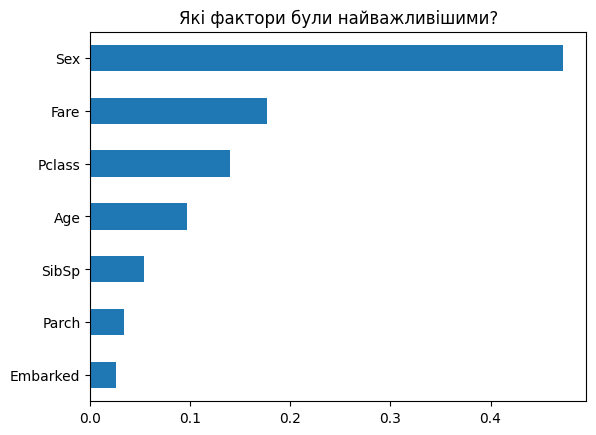

In [19]:
import matplotlib.pyplot as plt

features = pd.Series(clf.feature_importances_, index=X.columns)
features.sort_values().plot(kind='barh')
plt.title('Які фактори були найважливішими?')
plt.show()

### Результат на Kaggle: 0.77751
